## Get data from Zenodo

In [1]:
import subprocess
import os

output_dir = './data/'
os.makedirs(output_dir, exist_ok=True)

cmd1 = ["wget", "-c", "-P", output_dir, "https://zenodo.org/records/17143346/files/PE_O5Like_snr20.h5"] # PE file
cmd2 = ["wget", "-c", "-P", output_dir, "https://zenodo.org/records/17143346/files/injections_Ninj_2e7_O5Like_snr20.h5"] # inj file
subprocess.run(cmd1, capture_output=True, text=True)
subprocess.run(cmd2, capture_output=True, text=True)

CompletedProcess(args=['wget', '-c', '-P', './data/', 'https://zenodo.org/records/17143346/files/injections_Ninj_2e7_O5Like_snr20.h5'], returncode=0, stdout='', stderr='--2026-09-10 14:25:22--  https://zenodo.org/records/17143346/files/injections_Ninj_2e7_O5Like_snr20.h5\nResolving zenodo.org (zenodo.org)... 188.185.43.153, 137.138.153.219, 137.138.52.235, ...\nConnecting to zenodo.org (zenodo.org)|188.185.43.153|:443... connected.\nHTTP request sent, awaiting response... 416 REQUESTED_RANGE_NOT_SATISFIABLE\n\n    The file is already fully retrieved; nothing to do.\n\n')

## Load data

In [2]:
import os, sys
os.environ['CHIMERA_USE_x64'] = "True"
os.environ['CHIMERA_ENABLE_GPU'] = "True"
sys.path.append(os.getcwd()+'/../')
from CHIMERA import data as data
import jax.numpy as jnp 

file_ev   =  "./data/PE_O5Like_snr20.h5"
theta_pe_det = data.load_gw_pe_samples(file_ev, 
                                 parameters=['m1det', 'm2det', 'dL'], 
                                 return_struct=True)
pe_prior = theta_pe_det.dL**2
theta_pe_det = theta_pe_det.update(pe_prior=pe_prior)
nev = len(theta_pe_det.dL)
print(f'Loaded {nev} GW events')

a = jnp.array([1.0])
a.dtype

2026-09-10 14:25:36,927 - CHIMERA - INFO - Loading `CHIMERA`. GPU acceleration: True. USE x64: True.


Loaded 300 GW events


dtype('float64')

## Instantiate population model

In [6]:
from CHIMERA.cosmo import flrw
from CHIMERA.mass.conditioned import plp
from CHIMERA.rate import madau_dickinson
from CHIMERA import population

# define population models with some fiducials
cosmo = flrw(H0 = 70., 
             Om0=0.25, 
             z_max = 5.)
mass = plp(m_low=5.1, m_high=87, lambda_peak=0.039, alpha=3.4, beta=1.1, delta_m=4.8, mu_g=34., sigma_g=3.6)
rate = madau_dickinson(gamma = 2.7,
                       kappa =  3.,
                       zp = 2.)

pop_model = population(cosmo, mass, rate, scale_free=True)

## Instantiate the Selection Function module

In [4]:
from CHIMERA import selection_function

file_inj = "./data/injections_Ninj_2e7_O5Like_snr20.h5"
theta_inj_det = data.load_injection_data(file_inj, snr_cut=20, key_mapping={'snr':'SNR_net', 'log_pdraw':'log_p_draw_nospin'}, frame='source')

sel_fcn = selection_function(theta_inj_det, N_inj=20*1e6)

## Instantiate the Hyperlike

In [7]:
from CHIMERA import hyperlikelihood
import jax

hyperlike = hyperlikelihood(  # data
  theta_gw_det = theta_pe_det,
  # population 
  population=pop_model,
  # integration grid resolution
  z_grids_res = 300,  
  # selection function
  selection_function=sel_fcn,
  # numerical stability
  pe_neff = 2.0,
  inj_neff = None, # default to 5*Nev  
  # KDE settings
  kind_kde = 'fft',
  kernel = 'gaussian',
  kde_bw = None, # default to scott
  num_bins = 200,
)


2026-09-10 14:26:37,509 - CHIMERA - WARNING - `kde_bw` is None, using Scott rule for bandwidth.
2026-09-10 14:26:37,510 - CHIMERA - INFO - Created hyperlikelihood model. Using 300 GW events.


## 1d on H0

100it [00:12,  8.00it/s]


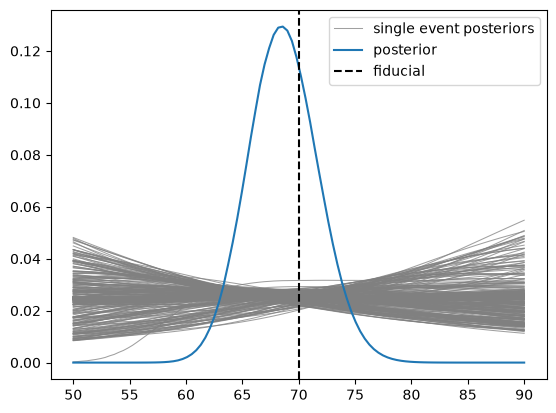

In [8]:
import numpy as np
import tqdm
import matplotlib.pyplot as plt

H0 = jnp.linspace(50, 90, 100)
log_like_evs_H0 = jnp.zeros((H0.shape[0], hyperlike.nevents))
loglike_H0 = jnp.zeros_like(H0)
N_exp_H0 = jnp.zeros_like(H0)

for i, h0 in tqdm.tqdm(enumerate(H0)):
  log_like_evs, N_exp, neff_inj, log_hyperlike = hyperlike.compute_all(H0=h0)
  log_like_evs_H0 = log_like_evs_H0.at[i].set(log_like_evs)
  N_exp_H0 = N_exp_H0.at[i].set(N_exp)
  loglike_H0 = loglike_H0.at[i].set(log_hyperlike)

# exponentiate and normalize
log_like_evs_H0 -= jnp.nanmax(log_like_evs_H0)
like_evs_H0 = jnp.exp(log_like_evs_H0) 
norms_evs = jnp.trapezoid(like_evs_H0, x=H0, axis=0)

loglike_H0 -= jnp.nanmax(loglike_H0)
like_H0 = jnp.exp(loglike_H0)
like_H0 /= jnp.trapezoid(like_H0, H0)

for e in range(hyperlike.nevents):
    lab = 'single event posteriors' if e == 0 else None
    plt.plot(H0, like_evs_H0[:,e]/norms_evs[e], c='gray', lw=0.75, alpha=0.75, label = lab )
plt.plot(H0, like_H0, label='posterior')
plt.axvline(70, ls='--', c='k', label= 'fiducial')
plt.legend()
plt.show()

In [ ]:
# Plot from loaded results
with h5py.File('results_float64.h5', 'r') as f64, h5py.File('results_float32.h5', 'r') as f32:
    trues_dict = dict(zip(
        [name.decode('utf-8') for name in f64.attrs['par_names']], 
        f64.attrs['trues']
    ))
    for par in priors:
        grp = f64[par]
        x = grp['x'][:]
        post64 = grp['post'][:]
        grad64 = grp['grad'][:]
        print(par, '64', np.isnan(grad64).sum())

        grp = f32[par]
        post32 = grp['post'][:]
        grad32 = grp['grad'][:]
        print(par, '32', np.isnan(grad32).sum())
        
        fig, axs = plt.subplots(1, 2, figsize=(10,4))
        axs[0].plot(x, post32)
        axs[1].plot(x, grad32)
        axs[0].plot(x, post64)
        axs[1].plot(x, grad64)
        for ax in axs:
            ax.set_xlabel(par)
            ax.axvline(trues_dict[par], c='k', ls='--')
        axs[1].axhline(0., c='k', ls='--')
        plt.show()

In [ ]:
# Plot from loaded results
with h5py.File('results_float64.h5', 'r') as f64, h5py.File('results_float32.h5', 'r') as f32:
    trues_dict = dict(zip(
        [name.decode('utf-8') for name in f64.attrs['par_names']], 
        f64.attrs['trues']
    ))
    for par in priors:
        grp = f64[par]
        x = grp['x'][:]
        post64 = grp['post'][:]
        grad64 = grp['grad'][:]

        grp = f32[par]
        post32 = grp['post'][:]
        grad32 = grp['grad'][:]
        
        fig, axs = plt.subplots(1, 2, figsize=(10,4))
        axs[0].plot(x, post64 - post32, label = 'post64 - post32')
        axs[1].plot(x, grad64 - grad32, label = 'grad64 - grad32')
        for ax in axs:
            ax.legend()
            ax.set_xlabel(par)
            ax.axhline(0., c='k', ls='--')
        plt.savefig(f'diff_{par}.png')
        plt.show()

In [ ]:
with h5py.File('results_float32.h5', 'r') as f32, h5py.File('results_float64.h5', 'r') as f64:
    #plt.plot(f32['H0']['x'][:], f32['H0']['grad'][:])
    plt.plot(f64['H0']['x'][:], f64['H0']['grad'][:])
    